In [7]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from numpy.random import seed
from numpy.random import randint
from numpy.random import randn
import seaborn as sns
import statistics
import string
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import sklearn
from bs4 import BeautifulSoup
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
Eng_Premier = pd.read_excel("/content/drive/MyDrive/Dissertation_19247207/Dataset/Eng_Premier.xlsx")
Eng_Premier

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Ast.1,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1,Matches
0,1,Max Aarons,ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Matches
1,22,Joshua Acheampong,ENG,DF,Chelsea,eng Premier League,18.0,2006.0,4,2,...,0.00,0.00,0.00,0.00,0.12,0.00,0.12,0.12,0.12,Matches
2,26,Tyler Adams,USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,...,0.14,0.14,0.00,0.14,0.07,0.05,0.12,0.07,0.12,Matches
3,28,Tosin Adarabioyo,ENG,DF,Chelsea,eng Premier League,26.0,1997.0,22,15,...,0.06,0.13,0.06,0.13,0.06,0.01,0.07,0.06,0.07,Matches
4,31,Simon Adingra,CIV,"FW,MF",Brighton,eng Premier League,22.0,2002.0,29,12,...,0.16,0.33,0.16,0.33,0.20,0.20,0.40,0.20,0.40,Matches
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,2802,Ashley Young,ENG,DF,Everton,eng Premier League,39.0,1985.0,32,19,...,0.14,0.19,0.05,0.19,0.01,0.11,0.12,0.01,0.12,Matches
570,2804,Illia Zabarnyi,UKR,DF,Bournemouth,eng Premier League,21.0,2002.0,36,35,...,0.03,0.03,0.00,0.03,0.04,0.02,0.06,0.04,0.06,Matches
571,2840,Oleksandr Zinchenko,UKR,"DF,MF",Arsenal,eng Premier League,27.0,1996.0,15,5,...,0.17,0.17,0.00,0.17,0.11,0.03,0.14,0.11,0.14,Matches
572,2842,Joshua Zirkzee,NED,"FW,MF",Manchester Utd,eng Premier League,23.0,2001.0,32,14,...,0.06,0.26,0.19,0.26,0.31,0.10,0.41,0.31,0.41,Matches


# Only Run when need to Scrape and then save it to Excel

In [ ]:

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 \
(KHTML, like Gecko) Chrome/87.0.4280.88 Safari/537.36'}

player_data = []

for player_name in Eng_Premier['Player']:
    url = f"https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query={player_name}"

    try:
        r = requests.get(url, headers=headers)
        r.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for {player_name}: {e}")
        player_data.append({'Player': player_name, 'Number': None, 'Name': None, 'Position': None, 'Age': None, 'Nation': None, 'Team': None, 'Value': None})
        time.sleep(1)
        continue

    soup = BeautifulSoup(r.text, 'html.parser')

    player_info = soup.find_all('tr', class_=['odd', 'even'])

    if not player_info:
        print(f"No player info found for {player_name}")
        player_data.append({'Player': player_name, 'Number': None, 'Name': None, 'Position': None, 'Age': None, 'Nation': None, 'Team': None, 'Value': None})
        time.sleep(1)
        continue

    info = player_info[0]
    player = info.find_all("td")

    try:
        number = player[0].text if len(player) > 0 else None
        name = player[3].text if len(player) > 3 else None
        position = player[4].text if len(player) > 4 else None
        age = player[5].text if len(player) > 5 else None
        nation = player[6].img['alt'] if len(player) > 6 and player[6].find('img') else None
        team = player[7].img['alt'] if len(player) > 7 and player[7].find('img') else None
        value = player[8].text.strip() if len(player) > 8 else None

        player_data.append({'Player': player_name, 'Number': number, 'Name': name, 'Position': position, 'Age': age, 'Nation': nation, 'Team': team, 'Value': value})

    except Exception as e:
        print(f"Error parsing data for {player_name}: {e}")
        player_data.append({'Player': player_name, 'Number': None, 'Name': None, 'Position': None, 'Age': None, 'Nation': None, 'Team': None, 'Value': None})


    time.sleep(1) # reducing load

scraped_df = pd.DataFrame(player_data)
display(scraped_df.head())

In [ ]:
scraped_df

,Player,Number,Name,Position,Age,Nation,Team,Value
0,Max Aarons,Max AaronsRangers FC,Rangers FC,RB,,None,England,€6.00m
1,Joshua Acheampong,Josh AcheampongChelsea FC,Chelsea FC,RB,,None,England,€8.00m
2,Tyler Adams,Tyler AdamsAFC Bournemouth,AFC Bournemouth,DM,,None,United States,€18.00m
3,Tosin Adarabioyo,Tosin AdarabioyoChelsea FC,Chelsea FC,CB,,None,England,€20.00m
4,Simon Adingra,Simon AdingraSunderland AFC,Sunderland AFC,LW,,None,Cote d'Ivoire,€28.00m
...,...,...,...,...,...,...,...,...
569,Ashley Young,Ashley YoungIpswich Town,Ipswich Town,RB,,None,England,€500k
570,Illia Zabarnyi,Ilya ZabarnyiParis Saint-Germain,Paris Saint-Germain,CB,,None,Ukraine,€42.00m
571,Oleksandr Zinchenko,Oleksandr ZinchenkoArsenal FC,Arsenal FC,LB,,None,Ukraine,€20.00m
572,Joshua Zirkzee,Joshua ZirkzeeManchester United,Manchester United,CF,,None,Netherlands,€30.00m


# Analysis

In [10]:
# scraped_df.to_excel("/content/drive/MyDrive/DissertationRetake/Dataset/Eng_Premier_PlayerValue.xlsx")
Eng_Premier_PlayerValue = pd.read_excel("//content/drive/MyDrive/Dissertation_19247207/Dataset/Eng_Premier_PlayerValue.xlsx")
Eng_Premier_PlayerValue

,Unnamed: 0,Player,Number,Name,Position,Age,Nation,Team,Value
0,0,Max Aarons,Max AaronsRangers FC,Rangers FC,RB,NaN,NaN,England,€6.00m
1,1,Joshua Acheampong,Josh AcheampongChelsea FC,Chelsea FC,RB,NaN,NaN,England,€8.00m
2,2,Tyler Adams,Tyler AdamsAFC Bournemouth,AFC Bournemouth,DM,NaN,NaN,United States,€18.00m
3,3,Tosin Adarabioyo,Tosin AdarabioyoChelsea FC,Chelsea FC,CB,NaN,NaN,England,€20.00m
4,4,Simon Adingra,Simon AdingraSunderland AFC,Sunderland AFC,LW,NaN,NaN,Cote d'Ivoire,€28.00m
...,...,...,...,...,...,...,...,...,...
569,569,Ashley Young,Ashley YoungIpswich Town,Ipswich Town,RB,NaN,NaN,England,€500k
570,570,Illia Zabarnyi,Ilya ZabarnyiParis Saint-Germain,Paris Saint-Germain,CB,NaN,NaN,Ukraine,€42.00m
571,571,Oleksandr Zinchenko,Oleksandr ZinchenkoArsenal FC,Arsenal FC,LB,NaN,NaN,Ukraine,€20.00m
572,572,Joshua Zirkzee,Joshua ZirkzeeManchester United,Manchester United,CF,NaN,NaN,Netherlands,€30.00m


In [11]:
Stats_MarketValue = pd.merge(Eng_Premier_PlayerValue, Eng_Premier, how="right", on=["Player"])

Stats_MarketValue

,Unnamed: 0,Player,Number,Name,Position,Age_x,Nation_x,Team,Value,Rk,...,Ast.1,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1,Matches
0,0,Max Aarons,Max AaronsRangers FC,Rangers FC,RB,NaN,NaN,England,€6.00m,1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Matches
1,1,Joshua Acheampong,Josh AcheampongChelsea FC,Chelsea FC,RB,NaN,NaN,England,€8.00m,22,...,0.00,0.00,0.00,0.00,0.12,0.00,0.12,0.12,0.12,Matches
2,2,Tyler Adams,Tyler AdamsAFC Bournemouth,AFC Bournemouth,DM,NaN,NaN,United States,€18.00m,26,...,0.14,0.14,0.00,0.14,0.07,0.05,0.12,0.07,0.12,Matches
3,3,Tosin Adarabioyo,Tosin AdarabioyoChelsea FC,Chelsea FC,CB,NaN,NaN,England,€20.00m,28,...,0.06,0.13,0.06,0.13,0.06,0.01,0.07,0.06,0.07,Matches
4,4,Simon Adingra,Simon AdingraSunderland AFC,Sunderland AFC,LW,NaN,NaN,Cote d'Ivoire,€28.00m,31,...,0.16,0.33,0.16,0.33,0.20,0.20,0.40,0.20,0.40,Matches
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,569,Ashley Young,Ashley YoungIpswich Town,Ipswich Town,RB,NaN,NaN,England,€500k,2802,...,0.14,0.19,0.05,0.19,0.01,0.11,0.12,0.01,0.12,Matches
594,570,Illia Zabarnyi,Ilya ZabarnyiParis Saint-Germain,Paris Saint-Germain,CB,NaN,NaN,Ukraine,€42.00m,2804,...,0.03,0.03,0.00,0.03,0.04,0.02,0.06,0.04,0.06,Matches
595,571,Oleksandr Zinchenko,Oleksandr ZinchenkoArsenal FC,Arsenal FC,LB,NaN,NaN,Ukraine,€20.00m,2840,...,0.17,0.17,0.00,0.17,0.11,0.03,0.14,0.11,0.14,Matches
596,572,Joshua Zirkzee,Joshua ZirkzeeManchester United,Manchester United,CF,NaN,NaN,Netherlands,€30.00m,2842,...,0.06,0.26,0.19,0.26,0.31,0.10,0.41,0.31,0.41,Matches


In [12]:
def convert_value_to_millions(value):
    """Converts a string value with '€', 'm', or 'k' to a numerical value in millions."""
    if isinstance(value, str):
        value = value.replace('€', '').strip()
        if 'm' in value:
            return float(value.replace('m', ''))
        elif 'k' in value:
            return float(value.replace('k', '')) / 1000
    return None

Stats_MarketValue['MarketValue_in_Millions'] = Stats_MarketValue['Value'].apply(convert_value_to_millions)

display(Stats_MarketValue[['Value', 'MarketValue_in_Millions']])

,Value,MarketValue_in_Millions
0,€6.00m,6.0
1,€8.00m,8.0
2,€18.00m,18.0
3,€20.00m,20.0
4,€28.00m,28.0
...,...,...
593,€500k,0.5
594,€42.00m,42.0
595,€20.00m,20.0
596,€30.00m,30.0


In [13]:
Stats_MarketValue.rename(columns={'Name': 'Club_Name'}, inplace=True)

Stats_MarketValue

,Unnamed: 0,Player,Number,Club_Name,Position,Age_x,Nation_x,Team,Value,Rk,...,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1,Matches,MarketValue_in_Millions
0,0,Max Aarons,Max AaronsRangers FC,Rangers FC,RB,NaN,NaN,England,€6.00m,1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Matches,6.0
1,1,Joshua Acheampong,Josh AcheampongChelsea FC,Chelsea FC,RB,NaN,NaN,England,€8.00m,22,...,0.00,0.00,0.00,0.12,0.00,0.12,0.12,0.12,Matches,8.0
2,2,Tyler Adams,Tyler AdamsAFC Bournemouth,AFC Bournemouth,DM,NaN,NaN,United States,€18.00m,26,...,0.14,0.00,0.14,0.07,0.05,0.12,0.07,0.12,Matches,18.0
3,3,Tosin Adarabioyo,Tosin AdarabioyoChelsea FC,Chelsea FC,CB,NaN,NaN,England,€20.00m,28,...,0.13,0.06,0.13,0.06,0.01,0.07,0.06,0.07,Matches,20.0
4,4,Simon Adingra,Simon AdingraSunderland AFC,Sunderland AFC,LW,NaN,NaN,Cote d'Ivoire,€28.00m,31,...,0.33,0.16,0.33,0.20,0.20,0.40,0.20,0.40,Matches,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,569,Ashley Young,Ashley YoungIpswich Town,Ipswich Town,RB,NaN,NaN,England,€500k,2802,...,0.19,0.05,0.19,0.01,0.11,0.12,0.01,0.12,Matches,0.5
594,570,Illia Zabarnyi,Ilya ZabarnyiParis Saint-Germain,Paris Saint-Germain,CB,NaN,NaN,Ukraine,€42.00m,2804,...,0.03,0.00,0.03,0.04,0.02,0.06,0.04,0.06,Matches,42.0
595,571,Oleksandr Zinchenko,Oleksandr ZinchenkoArsenal FC,Arsenal FC,LB,NaN,NaN,Ukraine,€20.00m,2840,...,0.17,0.00,0.17,0.11,0.03,0.14,0.11,0.14,Matches,20.0
596,572,Joshua Zirkzee,Joshua ZirkzeeManchester United,Manchester United,CF,NaN,NaN,Netherlands,€30.00m,2842,...,0.26,0.19,0.26,0.31,0.10,0.41,0.31,0.41,Matches,30.0


In [14]:
Stats_MarketValue['Club_Name'].unique()


array(['Rangers FC', 'Chelsea FC', 'AFC Bournemouth', 'Sunderland AFC',
       'Wolverhampton Wanderers', 'Crystal Palace U21',
       'Nottingham Forest', 'Manchester City', 'Brentford FC',
       'Everton FC', 'Real Madrid', 'Liverpool FC', 'Atlanta United FC',
       'Leicester City U18', 'Fenerbahce', 'Leicester City',
       'Manchester United', 'RC Strasbourg Alsace', 'Fulham FC',
       'Retired', 'Without Club', 'Southampton FC', 'West Ham United',
       'Arsenal FC', 'Paris Saint-Germain', 'Tottenham Hotspur',
       'Brighton & Hove Albion', 'AS Roma', 'Aston Villa',
       'Newcastle United', 'FC Porto', nan, 'Wrexham AFC', 'Burnley FC',
       'Swansea City', 'Ipswich Town', 'FC Lausanne-Sport',
       'Leeds United', 'Birmingham City', 'Crystal Palace',
       'West Bromwich Albion', 'TSG 1899 Hoffenheim', 'Stoke City',
       'CR Flamengo', 'Liverpool FC U21', 'SSC Napoli', 'Bayern Munich',
       'Everton FC U21', 'Aberdeen FC', 'NEOM SC', 'Bayer 04 Leverkusen',
       

In [15]:
# Stats_MarketValue['CR']=0
# for i in range(0,len(Stats_MarketValue)):
#     if(Stats_MarketValue['Club_Name'][i]=='PSG' or Stats_MarketValue['Club_Name'][i]=='Manchester Utd' or Stats_MarketValue['Club_Name'][i]=='Liverpool' or Stats_MarketValue['Club_Name'][i]=='Real Madrid' or Stats_MarketValue['Club_Name'][i]=='Barcelona' or Stats_MarketValue['Club_Name'][i]=='Bayern Munich' or Stats_MarketValue['Club_Name'][i]=='Juventus' or Stats_MarketValue['Club_Name'][i]=='Atlético Madrid' or Stats_MarketValue['Club_Name'][i]=='Inter' or Stats_MarketValue['Club_Name'][i]=='Chelsea' or Stats_MarketValue['Club_Name'][i]=='Manchester City' ):
#         Stats_MarketValue['CR'][i]=1
#     elif(Stats_MarketValue['Club_Name'][i]=='Arsenal' or Stats_MarketValue['Club_Name'][i]=='Tottenham' or Stats_MarketValue['Club_Name'][i]=='Napoli' or Stats_MarketValue['Club_Name'][i]=='Dortmund' or Stats_MarketValue['Club_Name'][i]=='Leicester City' or Stats_MarketValue['Club_Name'][i]=='Lyon' or Stats_MarketValue['Club_Name'][i]=='Everton' or Stats_MarketValue['Club_Name'][i]=='Valencia' or Stats_MarketValue['Club_Name'][i]=='Sevilla' ):
#         Stats_MarketValue['CR'][i]=2
#     else:
#         Stats_MarketValue['CR'][i]=3

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Stats_MarketValue['CR'][i]=3
/tmp/ipython-input-4153035603.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Stats_MarketValue['CR'][i]=3
/tmp/ipython-input-4153035603.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting 

In [16]:
list(Stats_MarketValue.columns)

['Unnamed: 0',
 'Player',
 'Number',
 'Club_Name',
 'Position',
 'Age_x',
 'Nation_x',
 'Team',
 'Value',
 'Rk',
 'Nation_y',
 'Pos',
 'Squad',
 'Comp',
 'Age_y',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'npxG',
 'xAG',
 'npxG+xAG',
 'PrgC',
 'PrgP',
 'PrgR',
 'Gls.1',
 'Ast.1',
 'G+A.1',
 'G-PK.1',
 'G+A-PK',
 'xG.1',
 'xAG.1',
 'xG+xAG',
 'npxG.1',
 'npxG+xAG.1',
 'Matches',
 'MarketValue_in_Millions',
 'CR']

/tmp/ipython-input-1169053105.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(y='MarketValue_in_Millions', x='CR',data=Stats_MarketValue,palette="colorblind")


[Text(0.5, 0, 'Club Ranking'),
 Text(0, 0.5, 'Market Value in Million €'),
 Text(0.5, 1.0, 'MV vs Club')]

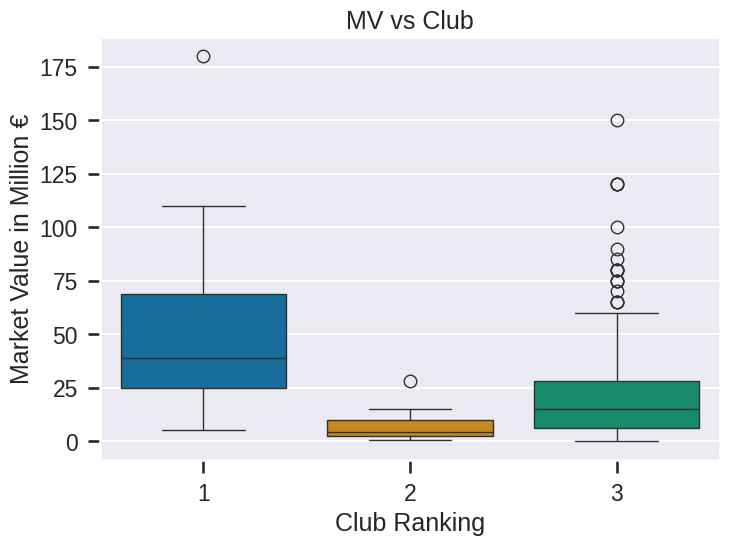

In [17]:
plt.style.use('seaborn-v0_8')
plt.tight_layout()
sns.set_context('talk')
ax=sns.boxplot(y='MarketValue_in_Millions', x='CR',data=Stats_MarketValue,palette="colorblind")
ax.set(xlabel='Club Ranking', ylabel='Market Value in Million €',title='MV vs Club')

In [18]:
import plotly.express as px

fig = px.box(Stats_MarketValue, y='MarketValue_in_Millions', x='CR', color='CR',
             labels={'CR': 'Club Ranking', 'MarketValue_in_Millions': 'Market Value in Million €'},
             title='MV vs Club')
fig.show()

## Data exploration



In [19]:
display(Stats_MarketValue.describe())
display(Stats_MarketValue.info())

,Unnamed: 0,Age_x,Nation_x,Rk,Age_y,Born,MP,Starts,Min,90s,...,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1,MarketValue_in_Millions,CR
count,598.000000,0.0,0.0,598.000000,594.000000,594.000000,598.000000,598.000000,598.000000,598.000000,...,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,574.000000,598.000000
mean,283.607023,NaN,NaN,1428.135452,25.087542,1998.531987,19.759197,14.232441,1278.806020,14.208027,...,0.189615,0.104114,0.184716,0.147625,0.096405,0.243696,0.142742,0.238712,21.253571,2.874582
std,166.727165,NaN,NaN,832.222175,4.422739,4.450191,12.226185,12.242298,1048.861046,11.654466,...,0.263338,0.171086,0.255443,0.293498,0.123536,0.338953,0.289734,0.333900,21.537429,0.443818
min,0.000000,NaN,NaN,1.000000,15.000000,1985.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.075000,1.000000
25%,139.250000,NaN,NaN,748.750000,22.000000,1996.000000,8.250000,2.250000,313.500000,3.500000,...,0.000000,0.000000,0.000000,0.020000,0.010000,0.050000,0.020000,0.050000,6.000000,3.000000
50%,282.500000,NaN,NaN,1350.500000,25.000000,1999.000000,20.000000,12.000000,1060.000000,11.800000,...,0.090000,0.000000,0.090000,0.070000,0.060000,0.140000,0.070000,0.140000,15.000000,3.000000
75%,427.000000,NaN,NaN,2179.000000,28.000000,2002.000000,31.000000,25.000000,2187.250000,24.275000,...,0.290000,0.150000,0.290000,0.200000,0.150000,0.350000,0.190000,0.347500,28.000000,3.000000
max,573.000000,NaN,NaN,2852.000000,39.000000,2008.000000,38.000000,38.000000,3420.000000,38.000000,...,2.650000,1.640000,2.650000,5.060000,1.450000,5.060000,5.060000,5.060000,180.000000,3.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               598 non-null    int64  
 1   Player                   598 non-null    object 
 2   Number                   588 non-null    object 
 3   Club_Name                588 non-null    object 
 4   Position                 588 non-null    object 
 5   Age_x                    0 non-null      float64
 6   Nation_x                 0 non-null      float64
 7   Team                     588 non-null    object 
 8   Value                    588 non-null    object 
 9   Rk                       598 non-null    int64  
 10  Nation_y                 594 non-null    object 
 11  Pos                      598 non-null    object 
 12  Squad                    598 non-null    object 
 13  Comp                     598 non-null    object 
 14  Age_y                    5

None

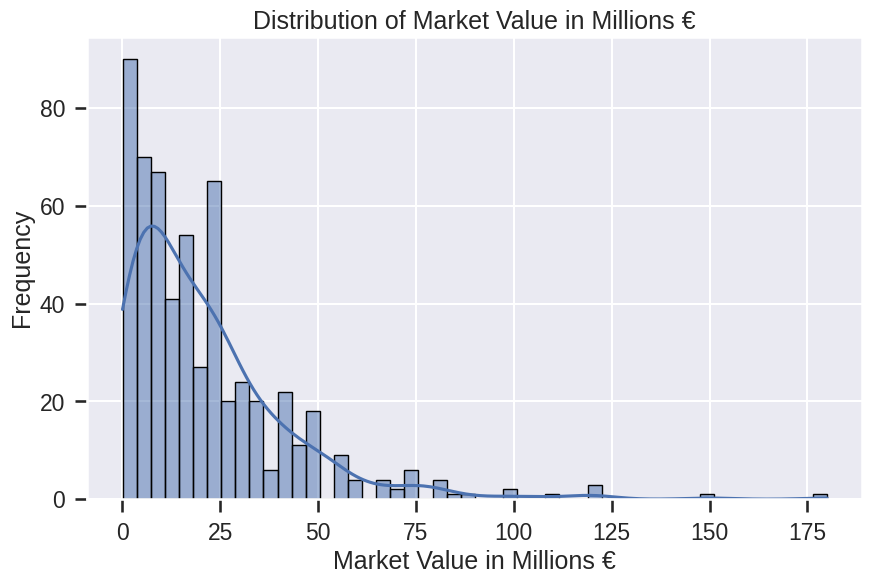

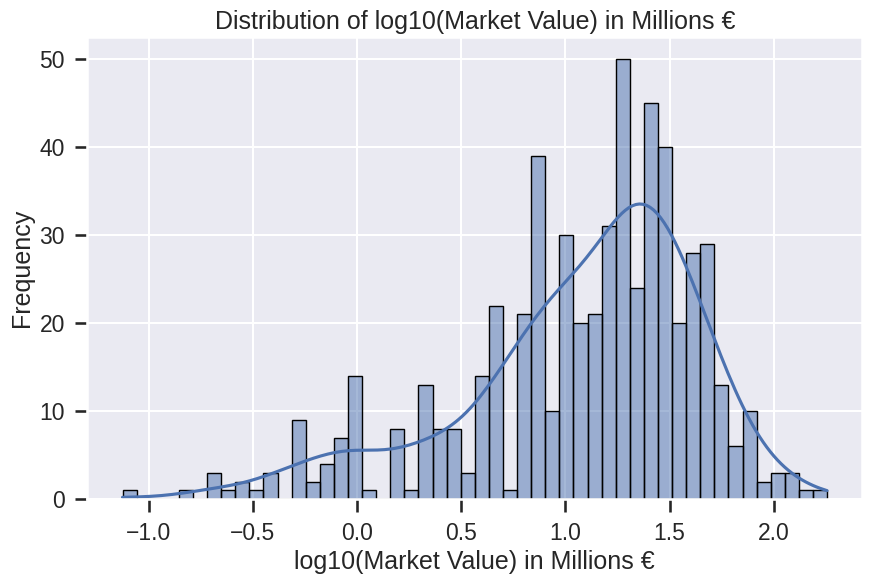

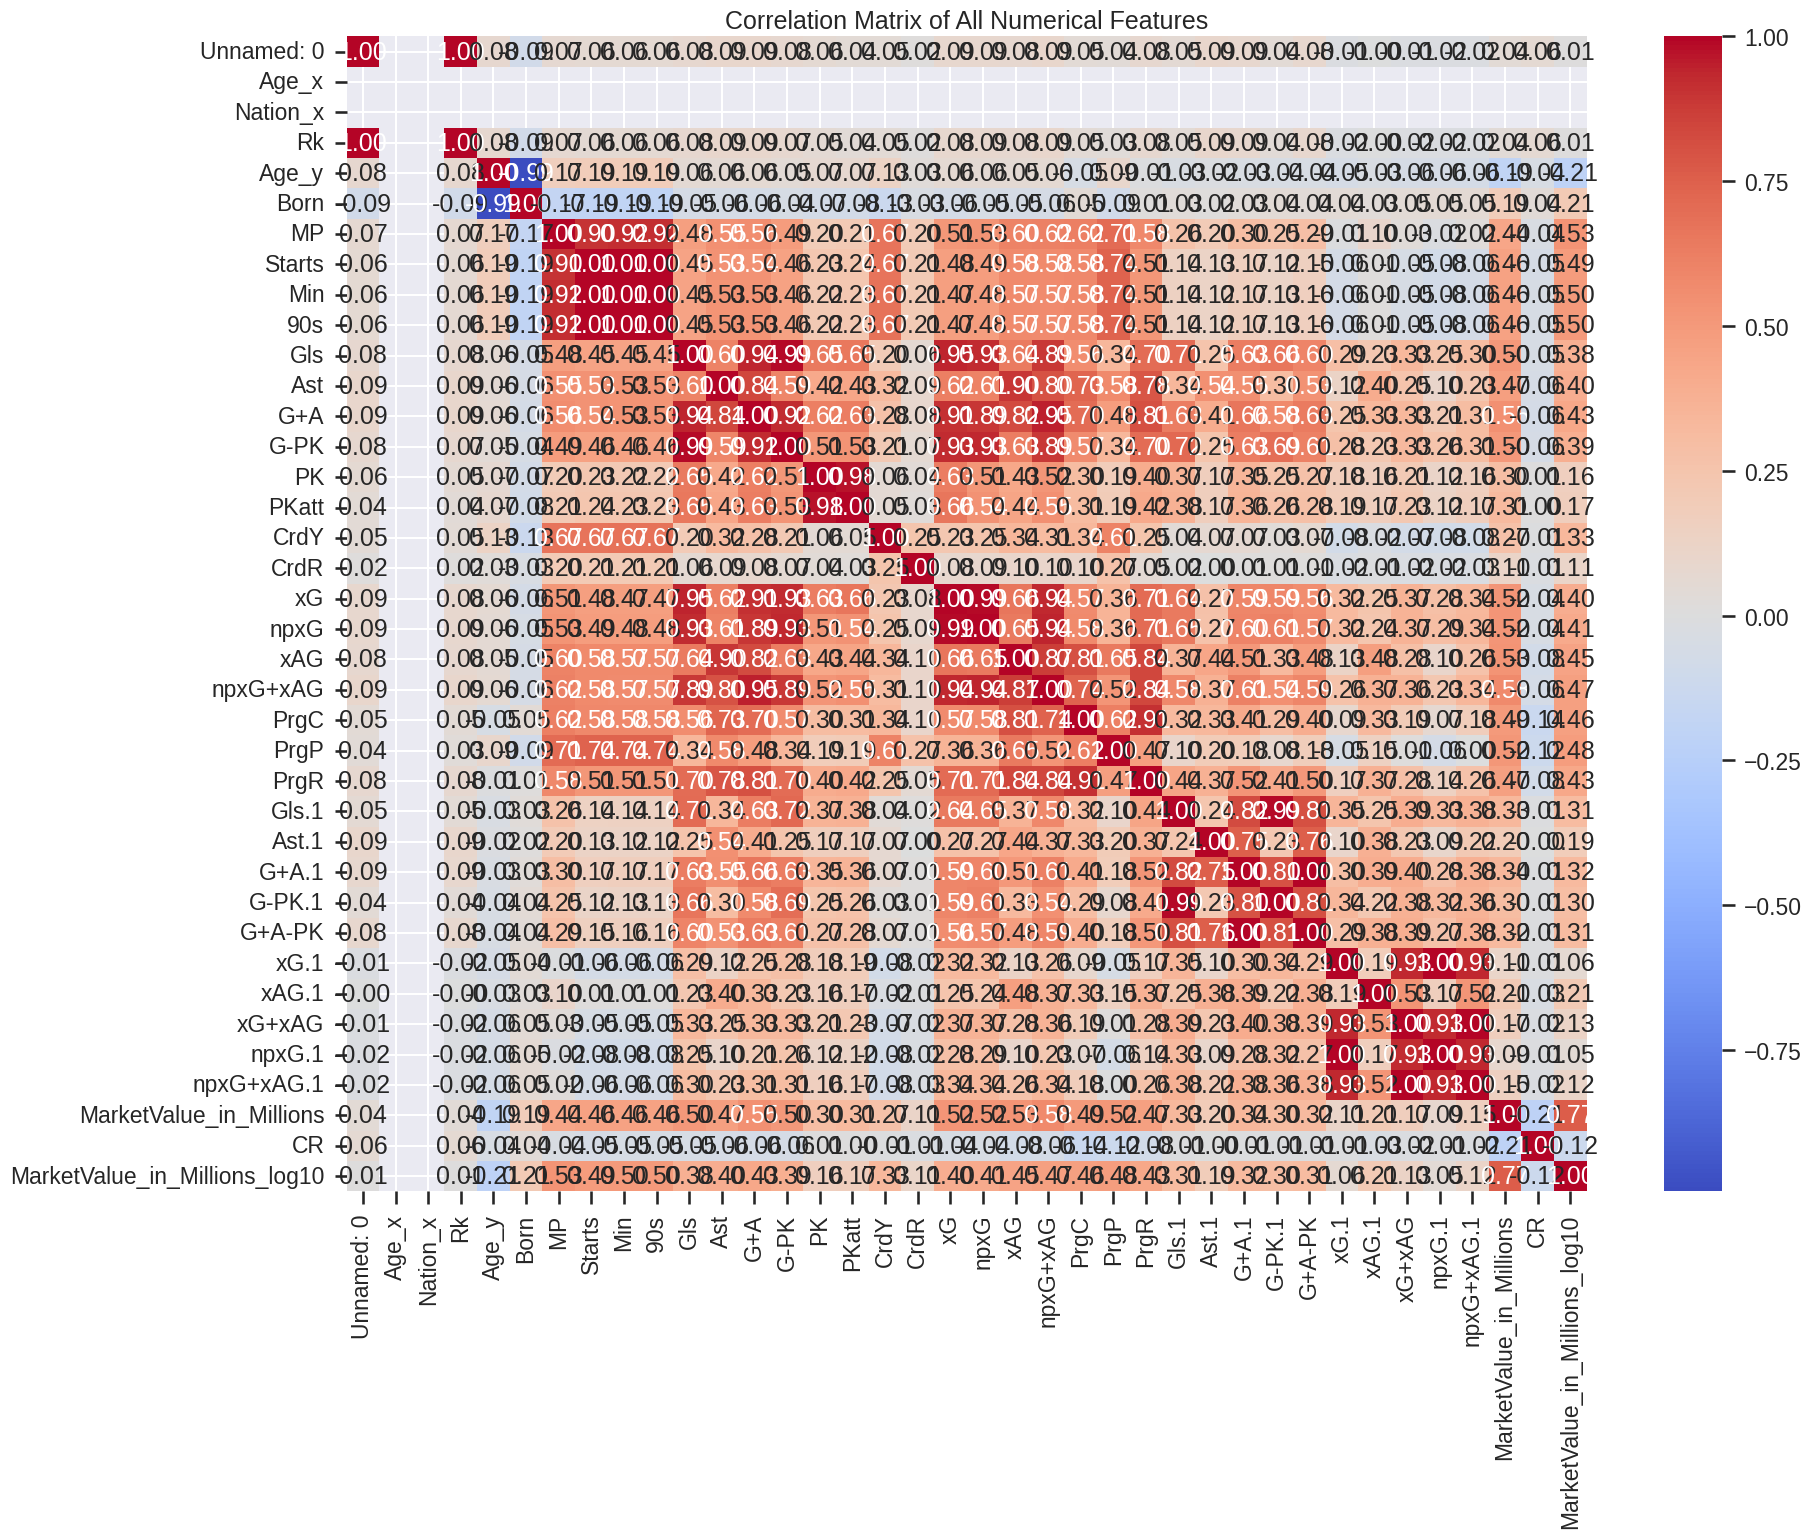

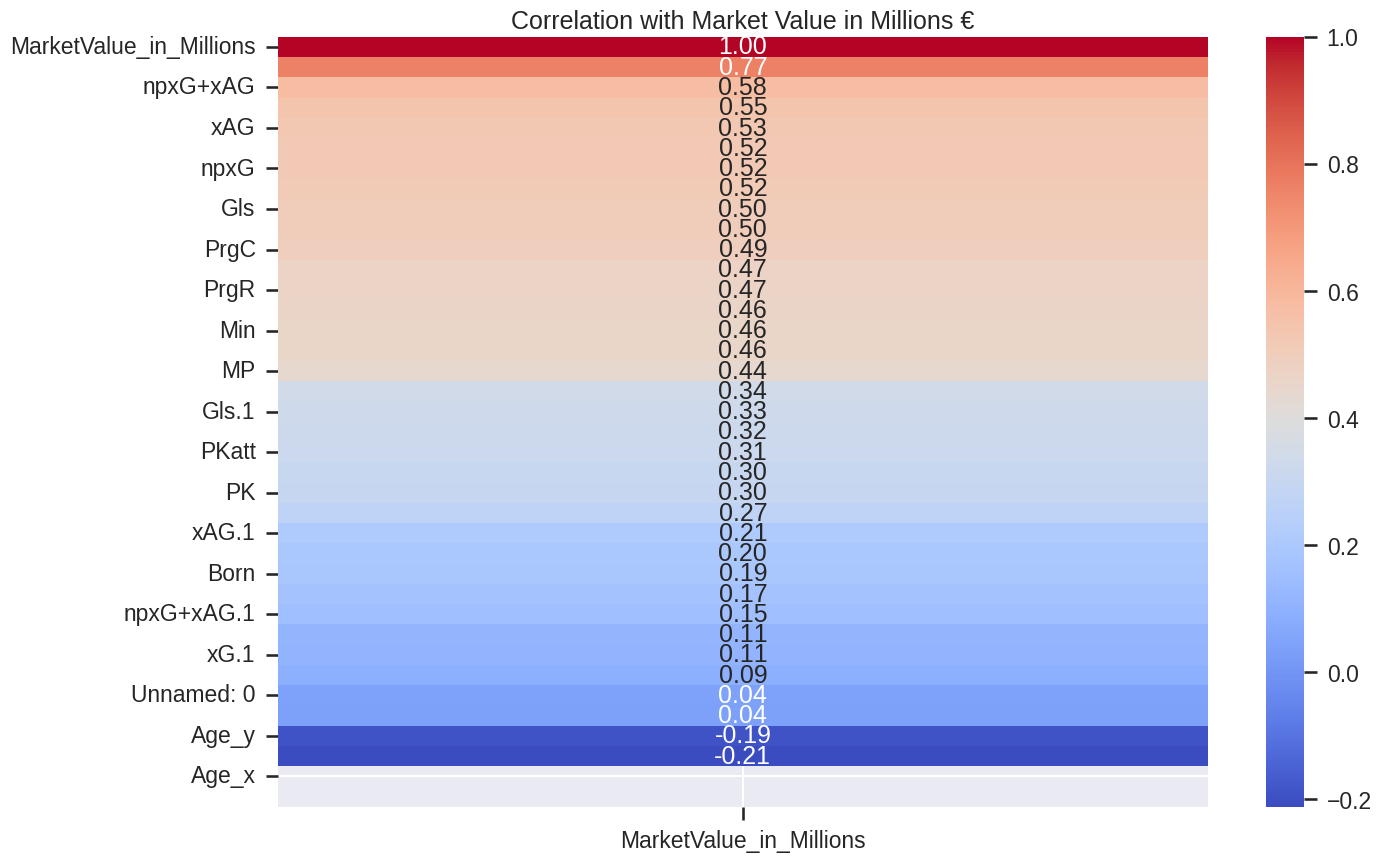

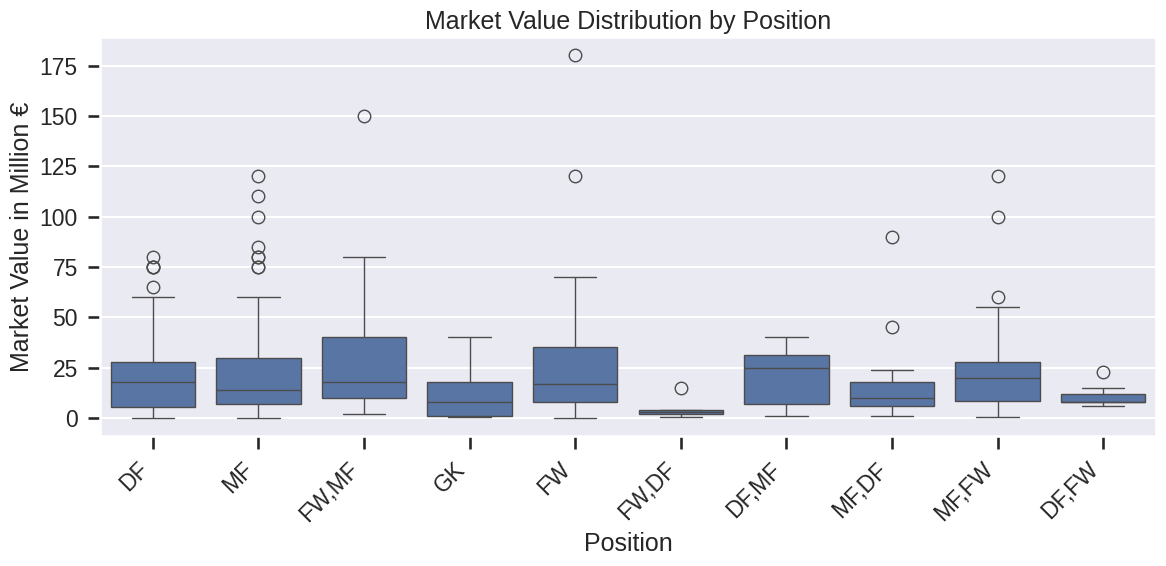

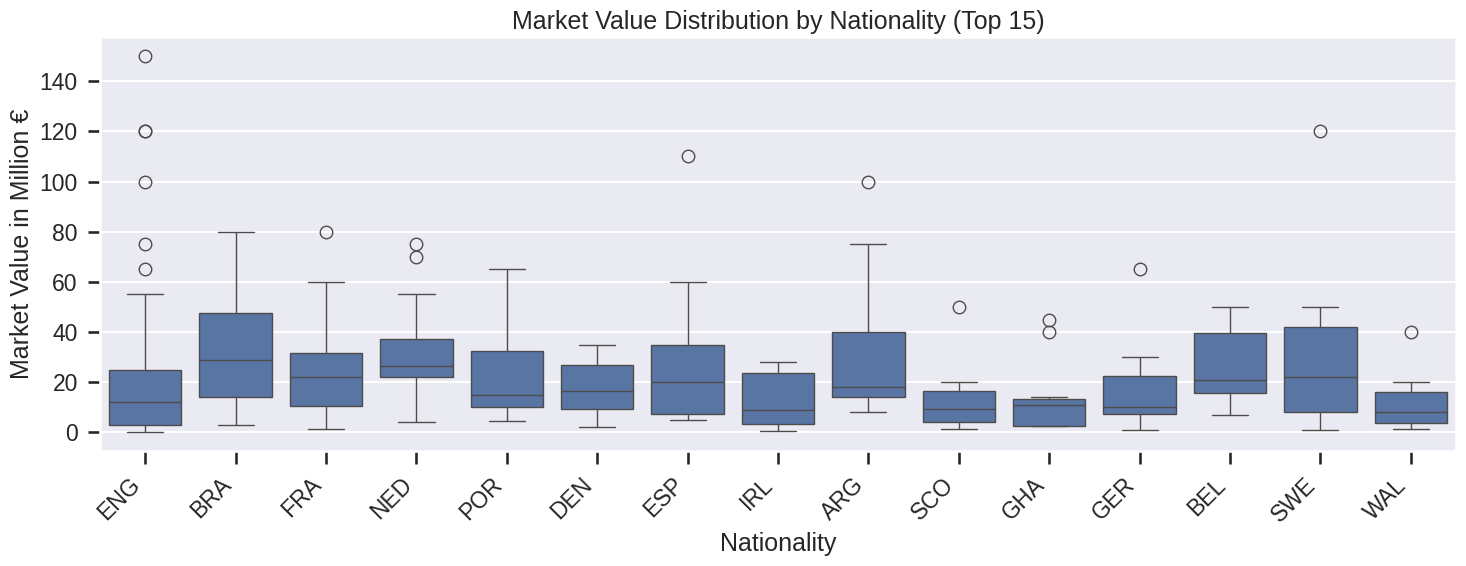

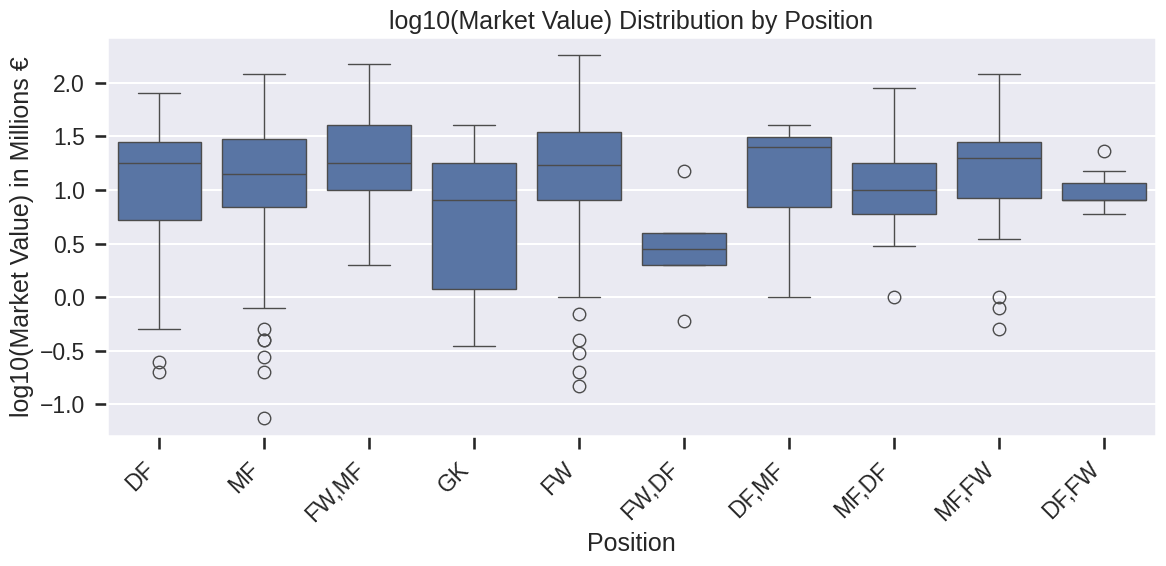

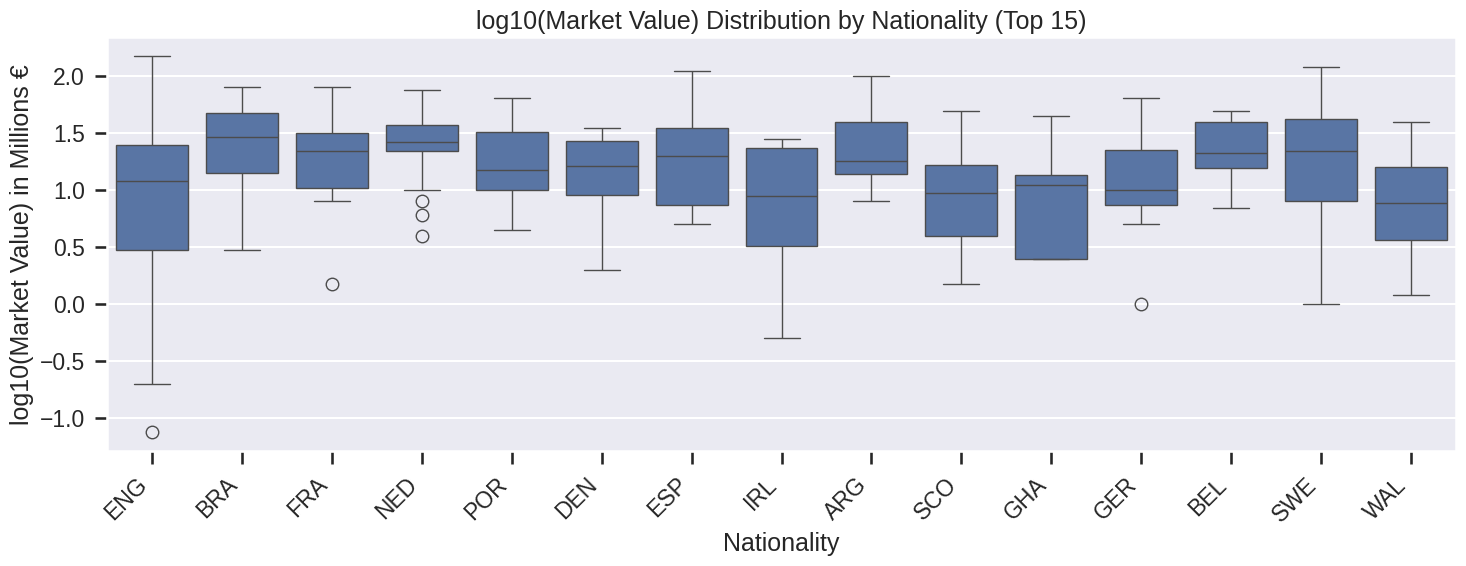

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(Stats_MarketValue['MarketValue_in_Millions'], bins=50, kde=True)
plt.title('Distribution of Market Value in Millions €')
plt.xlabel('Market Value in Millions €')
plt.ylabel('Frequency')
plt.show()


Stats_MarketValue['MarketValue_in_Millions_log10'] = np.log10(Stats_MarketValue['MarketValue_in_Millions'])

plt.figure(figsize=(10, 6))
sns.histplot(Stats_MarketValue['MarketValue_in_Millions_log10'], bins=50, kde=True)
plt.title('Distribution of log10(Market Value) in Millions €')
plt.xlabel('log10(Market Value) in Millions €')
plt.ylabel('Frequency')
plt.show()

# Calculate and display the correlation matrix for all numerical features
plt.figure(figsize=(20, 15))
correlation_matrix_all = Stats_MarketValue.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Numerical Features')
plt.show()


plt.figure(figsize=(15, 10))
correlation_matrix = Stats_MarketValue.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix[['MarketValue_in_Millions']].sort_values(by='MarketValue_in_Millions', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Market Value in Millions €')
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(y='MarketValue_in_Millions', x='Pos', data=Stats_MarketValue)
plt.title('Market Value Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Market Value in Million €')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(y='MarketValue_in_Millions', x='Nation_y', data=Stats_MarketValue, order=Stats_MarketValue['Nation_y'].value_counts().index[:15]) # Top 15 nations for clarity
plt.title('Market Value Distribution by Nationality (Top 15)')
plt.xlabel('Nationality')
plt.ylabel('Market Value in Million €')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Add box plots for log-transformed market value
plt.figure(figsize=(12, 6))
sns.boxplot(y='MarketValue_in_Millions_log10', x='Pos', data=Stats_MarketValue)
plt.title('log10(Market Value) Distribution by Position')
plt.xlabel('Position')
plt.ylabel('log10(Market Value) in Millions €')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(y='MarketValue_in_Millions_log10', x='Nation_y', data=Stats_MarketValue, order=Stats_MarketValue['Nation_y'].value_counts().index[:15]) # Top 15 nations for clarity
plt.title('log10(Market Value) Distribution by Nationality (Top 15)')
plt.xlabel('Nationality')
plt.ylabel('log10(Market Value) in Millions €')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#  Visualizing the distribution of 'MarketValue_in_Millions' using a histogram can help to understand its spread and identify potential skewness or outliers, and then create a correlation heatmap to explore relationships between numerical features and market value.

In [22]:
print("Unique values and counts for 'Pos':")
display(Stats_MarketValue['Pos'].value_counts())

print("\nUnique values and counts for 'Squad':")
display(Stats_MarketValue['Squad'].value_counts())

print("\nUnique values and counts for 'Nation_y':")
display(Stats_MarketValue['Nation_y'].value_counts().head(20)) # Display top 20 for brevity

#getting the unique values and their counts for categorical columns that could be relevant features for predicting market value to understand their cardinality and potential for use in modeling.

Unique values and counts for 'Pos':


,count
Pos,
DF,192
MF,115
FW,91
"FW,MF",65
"MF,FW",47
GK,44
"DF,MF",16
"MF,DF",13
"FW,DF",8



Unique values and counts for 'Squad':


,count
Squad,
Southampton,37
Brighton,34
Leicester City,34
Ipswich Town,34
Crystal Palace,33
Manchester Utd,32
Wolves,32
Chelsea,31
Tottenham,31



Unique values and counts for 'Nation_y':


,count
Nation_y,
ENG,204
BRA,34
FRA,30
NED,22
POR,22
DEN,21
ESP,19
IRL,18
ARG,17


In [23]:
# Feature engineering/selection
columns_to_drop = ['Unnamed: 0', 'Number', 'Age_x', 'Nation_x', 'Team', 'Value']
Stats_MarketValue_cleaned = Stats_MarketValue.drop(columns=columns_to_drop)

# Select potentially relevant features
numerical_features = [
    'Age_y', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK',
    'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP',
    'PrgR', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK', 'xG.1', 'xAG.1',
    'xG+xAG', 'npxG.1', 'npxG+xAG.1'
]

categorical_features = ['Pos', 'Squad', 'Nation_y']

Stats_MarketValue_cleaned['Age_y_squared'] = Stats_MarketValue_cleaned['Age_y']**2

numerical_features.append('Age_y_squared')

# Create a new DataFrame with selected features and the target variable
selected_features_df = Stats_MarketValue_cleaned[numerical_features + categorical_features + ['MarketValue_in_Millions']+["MarketValue_in_Millions_log10"]].copy()

display(selected_features_df.head())

,Age_y,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,...,xAG.1,xG+xAG,npxG.1,npxG+xAG.1,Age_y_squared,Pos,Squad,Nation_y,MarketValue_in_Millions,MarketValue_in_Millions_log10
0,24.0,3,1,86,1.0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,576.0,DF,Bournemouth,ENG,6.0,0.778151
1,18.0,4,2,170,1.9,0,0,0,0,0,...,0.00,0.12,0.12,0.12,324.0,DF,Chelsea,ENG,8.0,0.903090
2,25.0,28,21,1965,21.8,0,3,3,0,0,...,0.05,0.12,0.07,0.12,625.0,MF,Bournemouth,USA,18.0,1.255273
3,26.0,22,15,1409,15.7,1,1,2,1,0,...,0.01,0.07,0.06,0.07,676.0,DF,Chelsea,ENG,20.0,1.301030
4,22.0,29,12,1097,12.2,2,2,4,2,0,...,0.20,0.40,0.20,0.40,484.0,"FW,MF",Brighton,CIV,28.0,1.447158


In [24]:
# Checking for missing values
display(selected_features_df.isnull().sum())

,0
Age_y,4
MP,0
Starts,0
Min,0
90s,0
Gls,0
Ast,0
G+A,0
G-PK,0
PK,0


In [25]:
for col in ['Age_y', 'Age_y_squared', 'MarketValue_in_Millions','MarketValue_in_Millions_log10']:
    selected_features_df[col].fillna(selected_features_df[col].median(), inplace=True)

selected_features_df['Nation_y'].fillna(selected_features_df['Nation_y'].mode()[0], inplace=True)

display(selected_features_df.isnull().sum())

/tmp/ipython-input-3163675743.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-3163675743.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

,0
Age_y,0
MP,0
Starts,0
Min,0
90s,0
Gls,0
Ast,0
G+A,0
G-PK,0
PK,0


In [26]:
# Preprocessing
X = selected_features_df.drop(['MarketValue_in_Millions', 'MarketValue_in_Millions_log10'], axis=1)
y = selected_features_df['MarketValue_in_Millions_log10']

numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Shape of original features:", X.shape)
print("Shape of processed features:", X_processed.shape)
print("Shape of training features:", X_train.shape)
print("Shape of testing features:", X_test.shape)
print("Shape of training target:", y_train.shape)
print("Shape of testing target:", y_test.shape)

Shape of original features: (598, 34)
Shape of processed features: (598, 126)
Shape of training features: (478, 126)
Shape of testing features: (120, 126)
Shape of training target: (478,)
Shape of testing target: (120,)


In [27]:
# Model Selection and Training
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# import xgboost as xgb

linear_regression_model = LinearRegression()
ridge_model = Ridge()
lasso_model = Lasso()
random_forest_model = RandomForestRegressor(random_state=42)
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
# xgboost_model = xgb.XGBRegressor(random_state=42)


linear_regression_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
gradient_boosting_model.fit(X_train, y_train)
# xgboost_model.fit(X_train, y_train)


print("Models trained successfully.")

Models trained successfully.


Evaluation results for Linear Regression:
  Mean Absolute Error (MAE): 0.26
  Mean Squared Error (MSE): 0.15
  Root Mean Squared Error (RMSE): 0.39
  R-squared (R2): 0.57
------------------------------
Evaluation results for Ridge:
  Mean Absolute Error (MAE): 0.26
  Mean Squared Error (MSE): 0.15
  Root Mean Squared Error (RMSE): 0.38
  R-squared (R2): 0.58
------------------------------
Evaluation results for Lasso:
  Mean Absolute Error (MAE): 0.46
  Mean Squared Error (MSE): 0.35
  Root Mean Squared Error (RMSE): 0.59
  R-squared (R2): -0.00
------------------------------
Evaluation results for Random Forest:
  Mean Absolute Error (MAE): 0.24
  Mean Squared Error (MSE): 0.11
  Root Mean Squared Error (RMSE): 0.34
  R-squared (R2): 0.67
------------------------------
Evaluation results for Gradient Boosting:
  Mean Absolute Error (MAE): 0.21
  Mean Squared Error (MSE): 0.10
  Root Mean Squared Error (RMSE): 0.32
  R-squared (R2): 0.70
------------------------------


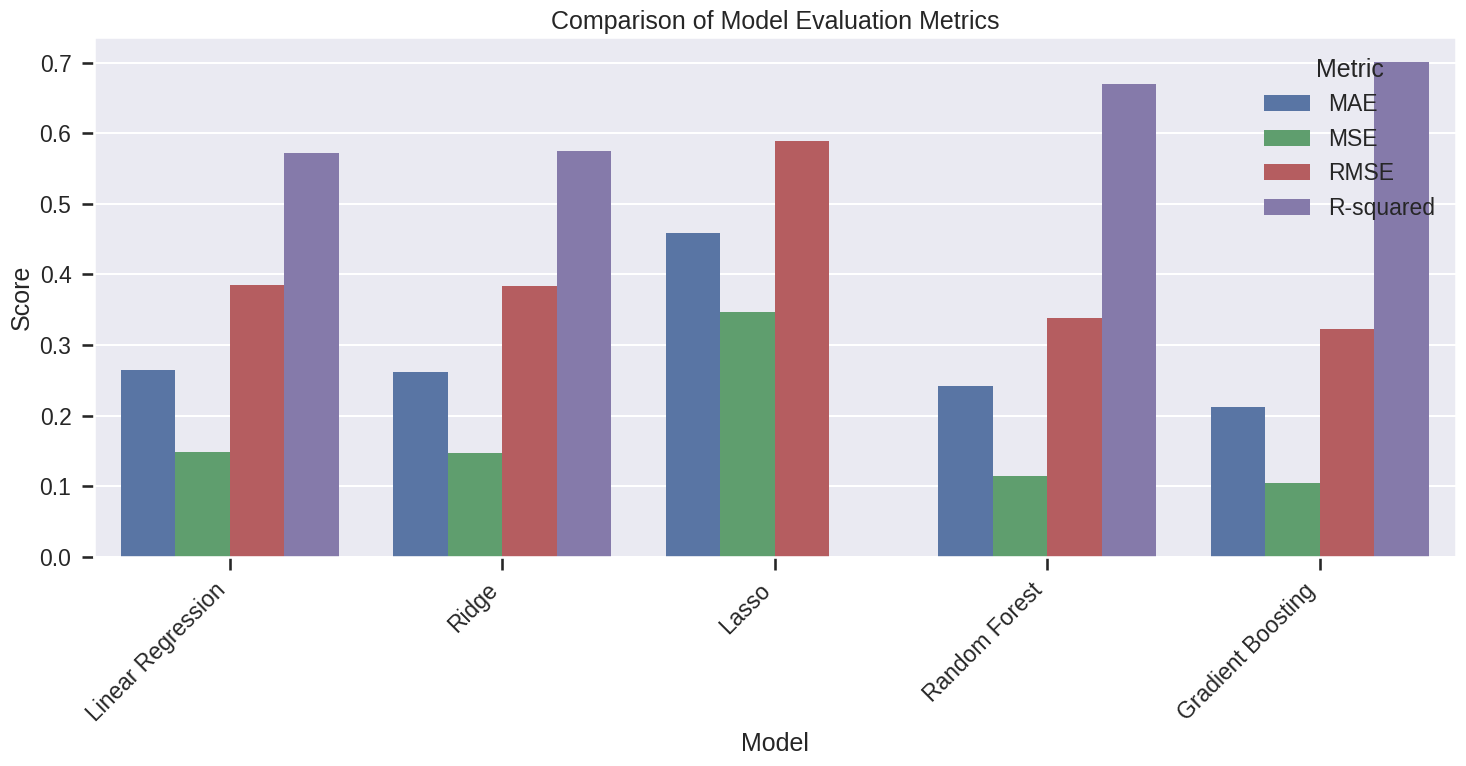

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

evaluation_results = {}

models = {
    "Linear Regression": linear_regression_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
    # "XGBoost": xgboost_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse) # Calculate RMSE
    r2 = r2_score(y_test, y_pred)
    evaluation_results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R-squared": r2} # Add RMSE to dictionary

for name, metrics in evaluation_results.items():
    print(f"Evaluation results for {name}:")
    print(f"  Mean Absolute Error (MAE): {metrics['MAE']:.2f}")
    print(f"  Mean Squared Error (MSE): {metrics['MSE']:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {metrics['RMSE']:.2f}") # Print RMSE
    print(f"  R-squared (R2): {metrics['R-squared']:.2f}")
    print("-" * 30)


evaluation_df = pd.DataFrame(evaluation_results).T.reset_index()
evaluation_df = evaluation_df.rename(columns={'index': 'Model'})

evaluation_melted = evaluation_df.melt(id_vars='Model', var_name='Metric', value_name='Score')



plt.figure(figsize=(15, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=evaluation_melted)
plt.title('Comparison of Model Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The best performing model is: Gradient Boosting

Top 20 Feature Importances:


,Feature,Importance
18,num__PrgP,0.253441
30,num__Age_y_squared,0.132698
16,num__npxG+xAG,0.102864
81,cat__Nation_y_ENG,0.058385
0,num__Age_y,0.057622
1,num__MP,0.044840
3,num__Min,0.043354
50,cat__Squad_Ipswich Town,0.032987
4,num__90s,0.029602
17,num__PrgC,0.024189


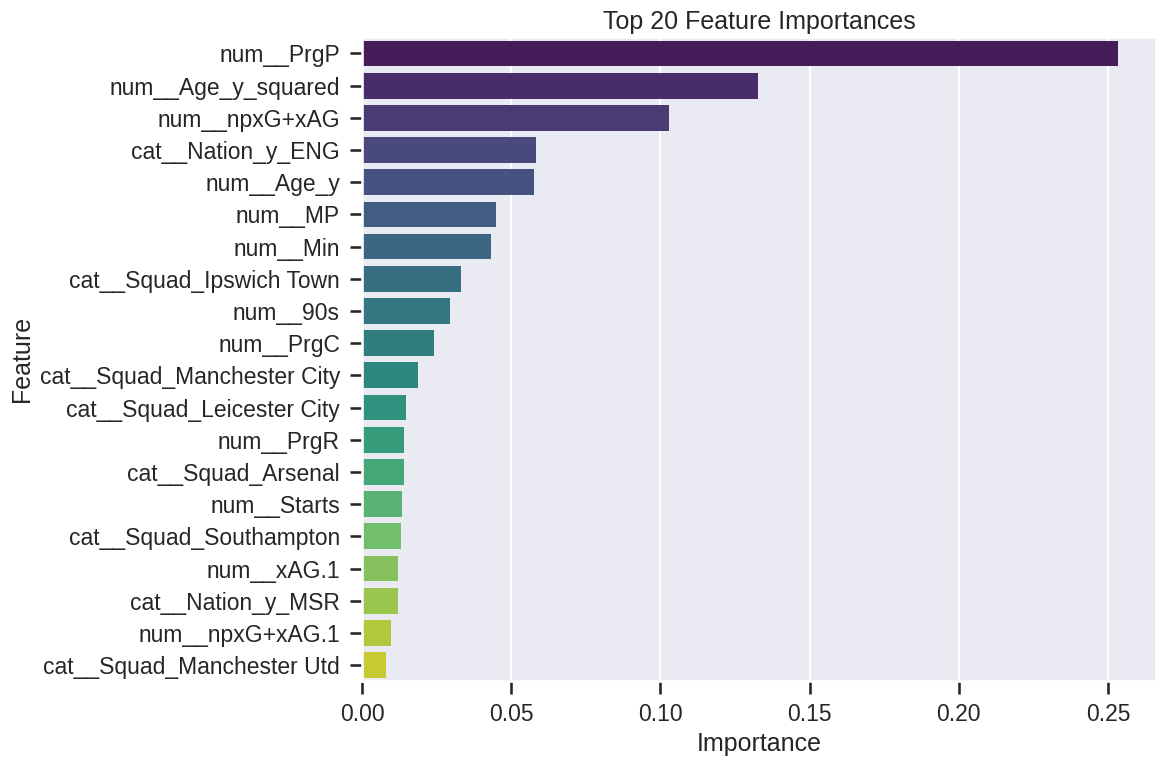

In [39]:
# Identify the best performing model based on R-squared from evaluation_results
best_model_name = max(evaluation_results, key=lambda k: evaluation_results[k]['R-squared'])
best_model = models[best_model_name]

print(f"The best performing model is: {best_model_name}")

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Get feature importances or coefficients based on the best model type
if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    print("\nTop 20 Feature Importances:")
    display(feature_importance_df.head(20))


    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis', hue='Feature', legend=False)
    plt.title('Top 20 Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


elif hasattr(best_model, 'coef_'):
    # Linear models
    coefficients = best_model.coef_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    feature_importance_df['Abs_Coefficient'] = abs(feature_importance_df['Coefficient'])
    feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')# Sort by absolute coefficient value
    print("\nTop 20 Feature Coefficients (by absolute value):")
    display(feature_importance_df.head(20))


    plt.figure(figsize=(12, 8))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df.head(20), palette='coolwarm', hue='Feature', legend=False)
    plt.title('Top 20 Feature Coefficients (by absolute value)')
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

else:
    print("\nFeature importance or coefficients not available for this model type.")

In [ ]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# evaluation_results = {}

# models = {
#     "Linear Regression": linear_regression_model,
#     "Ridge": ridge_model,
#     "Lasso": lasso_model,
#     "Random Forest": random_forest_model,
#     "Gradient Boosting": gradient_boosting_model
# }

# for name, model in models.items():
#     y_pred_log = model.predict(X_test)
#     # Transform predictions back to original scale
#     y_pred_original = 10**y_pred_log
#     # Transform actual values back to original scale for evaluation
#     y_test_original = 10**y_test

#     mae = mean_absolute_error(y_test_original, y_pred_original)
#     mse = mean_squared_error(y_test_original, y_pred_original)
#     r2 = r2_score(y_test_original, y_pred_original) # R-squared is scale-invariant, but calculating it on original scale is also fine
#     evaluation_results[name] = {"MAE (Original Scale)": mae, "MSE (Original Scale)": mse, "R-squared (Original Scale)": r2}

# for name, metrics in evaluation_results.items():
#     print(f"Evaluation results for {name}:")
#     print(f"  Mean Absolute Error (MAE) on Original Scale: {metrics['MAE (Original Scale)']:.2f}")
#     print(f"  Mean Squared Error (MSE) on Original Scale: {metrics['MSE (Original Scale)']:.2f}")
#     print(f"  R-squared (R2) on Original Scale: {metrics['R-squared (Original Scale)']:.2f}")
#     print("-" * 30)

In [ ]:
# best_model_name = max(evaluation_results, key=lambda k: evaluation_results[k]['R-squared (Original Scale)'])
# best_model = models[best_model_name]

# print(f"The best performing model is: {best_model_name}")

# # Get feature names after one-hot encoding
# feature_names = preprocessor.get_feature_names_out()

# # Get feature importances or coefficients based on the best model type
# if hasattr(best_model, 'feature_importances_'):
#     # Tree-based models
#     importances = best_model.feature_importances_
#     feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
#     feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
#     print("\nTop 20 Feature Importances:")
#     display(feature_importance_df.head(20))
# elif hasattr(best_model, 'coef_'):
#     # Linear models
#     coefficients = best_model.coef_
#     feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
#     # Sort by absolute coefficient value
#     feature_importance_df['Abs_Coefficient'] = abs(feature_importance_df['Coefficient'])
#     feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')
#     print("\nTop 20 Feature Coefficients (by absolute value):")
#     display(feature_importance_df.head(20))
# else:
#     print("\nFeature importance or coefficients not available for this model type.")

# Multilevel Modelling



In [30]:
%pip install statsmodels

In [31]:
statsmodels_df = selected_features_df.copy()


print("Data type of 'Squad' column:", statsmodels_df['Squad'].dtype)


statsmodels_df['Squad'] = statsmodels_df['Squad'].astype('category')

print("Data type of 'Squad' column after conversion:", statsmodels_df['Squad'].dtype)

display(statsmodels_df.head())

Data type of 'Squad' column: object
Data type of 'Squad' column after conversion: category


,Age_y,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,...,xAG.1,xG+xAG,npxG.1,npxG+xAG.1,Age_y_squared,Pos,Squad,Nation_y,MarketValue_in_Millions,MarketValue_in_Millions_log10
0,24.0,3,1,86,1.0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,576.0,DF,Bournemouth,ENG,6.0,0.778151
1,18.0,4,2,170,1.9,0,0,0,0,0,...,0.00,0.12,0.12,0.12,324.0,DF,Chelsea,ENG,8.0,0.903090
2,25.0,28,21,1965,21.8,0,3,3,0,0,...,0.05,0.12,0.07,0.12,625.0,MF,Bournemouth,USA,18.0,1.255273
3,26.0,22,15,1409,15.7,1,1,2,1,0,...,0.01,0.07,0.06,0.07,676.0,DF,Chelsea,ENG,20.0,1.301030
4,22.0,29,12,1097,12.2,2,2,4,2,0,...,0.20,0.40,0.20,0.40,484.0,"FW,MF",Brighton,CIV,28.0,1.447158


In [32]:
# Multilevel Modelling

import statsmodels.api as sm
from statsmodels.formula.api import gee
import re

# Define the model formula
# Include all numerical features and one-hot encoded categorical features except 'Squad'
# 'Squad' is used as the grouping variable


def sanitize_formula_name(name):
    name = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    if re.match(r'^[0-9]', name):
        name = '_' + name
    return name


sanitized_numerical_features = [sanitize_formula_name(name) for name in numerical_features]
sanitized_categorical_features = [sanitize_formula_name(name) for name in categorical_features.drop('Squad')]

statsmodels_df_sanitized = statsmodels_df.rename(columns={
    **dict(zip(numerical_features, sanitized_numerical_features)),
    **dict(zip(categorical_features.drop('Squad'), sanitized_categorical_features))
})

statsmodels_df_sanitized['Squad'] = statsmodels_df_sanitized['Squad'].astype('category')


formula = 'MarketValue_in_Millions_log10 ~ ' + ' + '.join(sanitized_numerical_features) + ' + ' + ' + '.join(sanitized_categorical_features)

print("Generated formula:", formula)


model = gee(formula, data=statsmodels_df_sanitized, groups=statsmodels_df_sanitized['Squad'], family=sm.families.Gaussian())


results = model.fit()


print(results.summary())

Generated formula: MarketValue_in_Millions_log10 ~ Age_y + MP + Starts + Min + _90s + Gls + Ast + G_A + G_PK + PK + PKatt + CrdY + CrdR + xG + npxG + xAG + npxG_xAG + PrgC + PrgP + PrgR + Gls_1 + Ast_1 + G_A_1 + G_PK_1 + G_A_PK + xG_1 + xAG_1 + xG_xAG + npxG_1 + npxG_xAG_1 + Age_y_squared + Pos + Nation_y
                                   GEE Regression Results                                   
Dep. Variable:        MarketValue_in_Millions_log10   No. Observations:                  598
Model:                                          GEE   No. clusters:                       20
Method:                                 Generalized   Min. cluster size:                  24
                               Estimating Equations   Max. cluster size:                  37
Family:                                    Gaussian   Mean cluster size:                29.9
Dependence structure:                  Independence   Num. iterations:                     2
Date:                              Mon, 22

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_estimating_equations.py:1842: RuntimeWarning:

invalid value encountered in sqrt



In [33]:
import statsmodels.api as sm
from statsmodels.formula.api import gee#, ols
import re


statsmodels_df_processed = selected_features_df.copy()

categorical_features_for_ohe = [col for col in categorical_features if col != 'Squad']


statsmodels_df_processed = pd.get_dummies(statsmodels_df_processed, columns=categorical_features_for_ohe, drop_first=True)
def sanitize_formula_name(name):
    name = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    if re.match(r'^[0-9]', name):
        name = '_' + name
    return name


all_feature_columns = [col for col in statsmodels_df_processed.columns if col not in ['MarketValue_in_Millions', 'MarketValue_in_Millions_log10', 'Squad']]


sanitized_feature_names = [sanitize_formula_name(name) for name in all_feature_columns]


feature_name_mapping = dict(zip(all_feature_columns, sanitized_feature_names))


statsmodels_df_processed = statsmodels_df_processed.rename(columns=feature_name_mapping)



if 'Squad' in statsmodels_df_processed.columns:
    statsmodels_df_processed['Squad'] = statsmodels_df_processed['Squad'].astype('category')
else:
    print("Error: 'Squad' column not found in the processed DataFrame.")



formula_mixedlm = 'MarketValue_in_Millions_log10 ~ 1 + ' + ' + '.join(sanitized_feature_names)

print("Generated MixedLM formula:", formula_mixedlm)

mixedlm_model_columns = sanitized_feature_names + ['MarketValue_in_Millions_log10', 'Squad']
statsmodels_df_model_final = statsmodels_df_processed[mixedlm_model_columns].copy()

print("\nData types before fitting the MixedLM model:")
print(statsmodels_df_model_final.dtypes)

object_cols_before_mixedlm = statsmodels_df_model_final.select_dtypes(include='object').columns
if len(object_cols_before_mixedlm) > 0:
    print(f"\nFound object columns before fitting MixedLM: {list(object_cols_before_mixedlm)}")
    for col in object_cols_before_mixedlm:
         if col != 'Squad': # Squad is handled separately as group
            try:
                statsmodels_df_model_final[col] = pd.to_numeric(statsmodels_df_model_final[col])
                print(f"Converted column '{col}' to numeric.")
            except ValueError:
                 statsmodels_df_model_final[col] = statsmodels_df_model_final[col].astype('category')
                 print(f"Converted column '{col}' to category.")
    print("\nData types after handling remaining object columns:")
    print(statsmodels_df_model_final.dtypes)



try:
    print("\nFitting the MixedLM model...")
    md = sm.MixedLM.from_formula(formula_mixedlm, data=statsmodels_df_model_final, groups=statsmodels_df_model_final['Squad'])
    mdf = md.fit(reml=False)

    print("MixedLM model fitted successfully.")
    print(mdf.summary())

except Exception as e:
    print(f"An error occurred while fitting the MixedLM model: {e}")
    print("Please ensure the data is prepared correctly and the formula is valid.")

Generated MixedLM formula: MarketValue_in_Millions_log10 ~ 1 + Age_y + MP + Starts + Min + _90s + Gls + Ast + G_A + G_PK + PK + PKatt + CrdY + CrdR + xG + npxG + xAG + npxG_xAG + PrgC + PrgP + PrgR + Gls_1 + Ast_1 + G_A_1 + G_PK_1 + G_A_PK + xG_1 + xAG_1 + xG_xAG + npxG_1 + npxG_xAG_1 + Age_y_squared + Pos_DF_FW + Pos_DF_MF + Pos_FW + Pos_FW_DF + Pos_FW_MF + Pos_GK + Pos_MF + Pos_MF_DF + Pos_MF_FW + Nation_y_ALG + Nation_y_ARG + Nation_y_AUS + Nation_y_AUT + Nation_y_BAN + Nation_y_BEL + Nation_y_BFA + Nation_y_BRA + Nation_y_CAN + Nation_y_CHI + Nation_y_CIV + Nation_y_CMR + Nation_y_COD + Nation_y_COL + Nation_y_CRO + Nation_y_CZE + Nation_y_DEN + Nation_y_ECU + Nation_y_EGY + Nation_y_ENG + Nation_y_ESP + Nation_y_FRA + Nation_y_GAB + Nation_y_GAM + Nation_y_GER + Nation_y_GHA + Nation_y_GNB + Nation_y_GRE + Nation_y_HUN + Nation_y_IRL + Nation_y_IRQ + Nation_y_ISL + Nation_y_ITA + Nation_y_JAM + Nation_y_JPN + Nation_y_KOR + Nation_y_KVX + Nation_y_MAR + Nation_y_MEX + Nation_y_MLI

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2704: RuntimeWarning:

invalid value encountered in sqrt



In [ ]:



if 'mdf' in locals() or 'mdf' in globals():
    print("Fixed Effects (Coefficients) from MixedLM Model:")
    display(mdf.summary().tables[1])

    num_fixed_effects = len(mdf.model.exog_names)


    fixed_effects_params = mdf.params[0:num_fixed_effects].reset_index(drop=True)
    fixed_effects_pvalues = mdf.pvalues[0:num_fixed_effects].reset_index(drop=True)


    feature_names_series = pd.Series(mdf.model.exog_names, name='Feature')

    fixed_effects_df = pd.DataFrame({
        'Feature': feature_names_series,
        'Coefficient': fixed_effects_params,
        'P-value': fixed_effects_pvalues
    })


    fixed_effects_df['Abs_Coefficient'] = abs(fixed_effects_df['Coefficient'])
    fixed_effects_df_sorted = fixed_effects_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

    print("\nFixed Effects Sorted by Absolute Coefficient:")
    display(fixed_effects_df_sorted)

    print("\nFixed Effects Sorted by P-value:")
    display(fixed_effects_df_sorted.sort_values(by='P-value'))

else:
    print("Error: The MixedLM model results (mdf) were not found.")
    print("Please ensure the cell where the MixedLM model is fitted has been executed successfully.")

Fixed Effects (Coefficients) from MixedLM Model:


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-2.290,0.528,-4.334,0.000,-3.326,-1.255
Pos_DF_FW[T.True],0.044,0.131,0.339,0.735,-0.212,0.301
Pos_DF_MF[T.True],0.048,0.090,0.535,0.593,-0.129,0.226
Pos_FW[T.True],-0.018,0.061,-0.292,0.770,-0.136,0.101
Pos_FW_DF[T.True],-0.017,0.126,-0.138,0.890,-0.265,0.230
...,...,...,...,...,...,...
xG_xAG,-12.525,9.477,-1.322,0.186,-31.100,6.050
npxG_1,-13.425,9.404,-1.428,0.153,-31.857,5.007
npxG_xAG_1,13.765,9.380,1.467,0.142,-4.619,32.150
Age_y_squared,-0.006,0.001,-10.109,0.000,-0.007,-0.005



Fixed Effects Sorted by Absolute Coefficient:


,Feature,Coefficient,P-value
97,G_PK_1,-20.868037,0.451745
98,G_A_PK,19.270886,0.504387
94,Gls_1,15.933495,0.560906
96,G_A_1,-14.073331,0.621926
103,npxG_xAG_1,13.765134,0.142242
...,...,...,...
77,Min,-0.001053,0.858848
91,PrgC,0.000843,0.537403
92,PrgP,0.000816,0.201024
93,PrgR,-0.000725,0.353167



Fixed Effects Sorted by P-value:


,Feature,Coefficient,P-value
104,Age_y_squared,-0.006109,5.015638e-24
74,Age_y,0.286098,9.140762e-20
0,Intercept,-2.290232,1.461225e-05
50,Nation_y_MSR[T.True],-1.506312,1.159584e-03
75,MP,0.010759,1.268419e-02
...,...,...,...
79,Gls,0.758414,9.999964e-01
80,Ast,1.330353,NaN
81,G_A,-1.323613,NaN
82,G_PK,0.579053,NaN
